# Lab Instructions

Choose your own adventure! In this lab, you will select a dataset, identify the target feature, and determine what relationships are present between the target and the other features in the data.

The dataset should have at least 5 features plus the target and at least a few hundred rows.  If the original dataset has more than 5 features, you may select the 5 that seem most interesting for this project. The subject can be anything you choose.  

For your lab submission, describe the dataset and the features - including all of the values of the features - and identify the target feature.  Then make visualizations to show the relationship of each feature to the target.  Which feature(s) seem most related?  Which features don't seem to influence the value of the target?  Draw at least one big picture conclusion about your data from the visualizations you've created.


# Lab: Exploring Feature Relationships with a Hallucination Detection Dataset

**Dataset:** `llm_rag_dataset_6k.csv.csv`  
**Source:** Kaggle  
**Goal:** Identify the target feature and explore how other features relate to it using visualizations.

## Dataset Overview
This dataset contains 6,000 LLM query/response records designed for research on hallucination detection and the effect of Retrieval-Augmented Generation (RAG). Each row compares model behavior with and without retrieval support.

For this lab, I selected the following features because they are the most useful for comparing the target to categorical and numeric variables:

1. `domain`
2. `hallucination_label_without_rag`
3. `hallucination_label_with_rag`
4. `hallucination_type`
5. `factual_consistency_score`
6. `context_relevance_score`
7. `source_support_label`

### Target Feature
I selected **`final_target_label`** as the target feature.

Based on the structure of the dataset, this target appears to represent whether the final response is labeled as hallucinated:

- `0` = not hallucinated / reliable final response
- `1` = hallucinated final response


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)
df = pd.read_csv("llm_rag_dataset_6k.csv.csv")

print("Shape:", df.shape)
display(df.head())

Shape: (6000, 14)


,sample_id,domain,question,ground_truth_answer,retrieved_context,llm_response_without_rag,llm_response_with_rag,hallucination_label_without_rag,hallucination_label_with_rag,hallucination_type,factual_consistency_score,context_relevance_score,source_support_label,final_target_label
0,1,technology,Please answer briefly: What does CPU stand for?,Central Processing Unit,"CPU stands for Central Processing Unit, the ma...",Computer Processing Utility.,"According to the retrieved context, Central Pr...",1,0,unsupported_claim,0.22,0.81,supported,0
1,2,biology,Can you answer this: What molecule carries gen...,DNA,DNA carries genetic information in living orga...,It is commonly stated as RNA only.,"According to the retrieved context, DNA.",1,0,factual_error,0.14,0.76,supported,0
2,3,finance,What is profit?,Revenue minus costs,Profit is what remains when costs are subtract...,The answer is A business debt.,"Using the retrieved evidence, Revenue minus co...",1,0,factual_error,0.31,0.89,supported,0
3,4,technology,"Using reliable knowledge, What does URL stand ...",Uniform Resource Locator,URL stands for Uniform Resource Locator.,The answer is Uniform Resource Locator.,"Using the retrieved evidence, Uniform Resource...",0,0,none,0.95,0.90,supported,0
4,5,technology,"Using reliable knowledge, What does HTML stand...",HyperText Markup Language,HTML stands for HyperText Markup Language.,The answer is HyperText Markup Language.,"According to the retrieved context, HyperText ...",0,0,none,0.99,0.90,supported,0


In [36]:
df.info()
df.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   sample_id                        6000 non-null   int64  
 1   domain                           6000 non-null   object 
 2   question                         6000 non-null   object 
 3   ground_truth_answer              6000 non-null   object 
 4   retrieved_context                6000 non-null   object 
 5   llm_response_without_rag         6000 non-null   object 
 6   llm_response_with_rag            6000 non-null   object 
 7   hallucination_label_without_rag  6000 non-null   int64  
 8   hallucination_label_with_rag     6000 non-null   int64  
 9   hallucination_type               6000 non-null   object 
 10  factual_consistency_score        6000 non-null   float64
 11  context_relevance_score          6000 non-null   float64
 12  source_support_label

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sample_id,6000.0,NaN,NaN,NaN,3000.5,1732.195139,1.0,1500.75,3000.5,4500.25,6000.0
domain,6000,10,history,803,NaN,NaN,NaN,NaN,NaN,NaN,NaN
question,6000,305,I need the correct answer: What organelle is k...,33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ground_truth_answer,6000,60,China,206,NaN,NaN,NaN,NaN,NaN,NaN,NaN
retrieved_context,6000,61,William Shakespeare wrote the tragedy 'Romeo a...,118,NaN,NaN,NaN,NaN,NaN,NaN,NaN
llm_response_without_rag,6000,867,The answer is Jane Austen.,33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
llm_response_with_rag,6000,470,"According to the retrieved context, China.",54,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hallucination_label_without_rag,6000.0,NaN,NaN,NaN,0.576333,0.49418,0.0,0.0,1.0,1.0,1.0
hallucination_label_with_rag,6000.0,NaN,NaN,NaN,0.077167,0.266878,0.0,0.0,0.0,0.0,1.0
hallucination_type,6000,5,none,2494,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Selected features and their values

Below are the selected features for the project and the values each feature can take.

### 1. `domain` (categorical)
Possible values:
- biology
- chemistry
- finance
- geography
- health
- history
- literature
- physics
- science
- technology

### 2. `hallucination_label_without_rag` (binary categorical)
Possible values:
- `0` = no hallucination without RAG
- `1` = hallucination without RAG

### 3. `hallucination_label_with_rag` (binary categorical)
Possible values:
- `0` = no hallucination with RAG
- `1` = hallucination with RAG

### 4. `hallucination_type` (categorical)
Possible values:
- contradiction
- factual_error
- none
- partially_correct
- unsupported_claim

### 5. `factual_consistency_score` (numeric)
Continuous score in this dataset, ranging from about **0.02 to 1.00**.

### 6. `context_relevance_score` (numeric)
Continuous score in this dataset, ranging from about **0.45 to 1.00**.

### 7. `source_support_label` (categorical)
Possible values:
- supported
- partially_supported
- not_supported

### Target: `final_target_label` (binary)
Possible values:
- `0` = final response is not hallucinated
- `1` = final response is hallucinated

In [37]:
selected_features = [
    "domain",
    "hallucination_label_without_rag",
    "hallucination_label_with_rag",
    "hallucination_type",
    "factual_consistency_score",
    "context_relevance_score",
    "source_support_label",
]

target = "final_target_label"

for col in selected_features + [target]:
    print(f"\n--- {col} ---")
    if df[col].dtype == "object":
        print(sorted(df[col].dropna().unique()))
    else:
        print("Unique values (first 20 shown):", sorted(df[col].dropna().unique())[:20])
        print("Min:", df[col].min(), "Max:", df[col].max())


--- domain ---
['biology', 'chemistry', 'finance', 'geography', 'health', 'history', 'literature', 'physics', 'science', 'technology']

--- hallucination_label_without_rag ---
Unique values (first 20 shown): [np.int64(0), np.int64(1)]
Min: 0 Max: 1

--- hallucination_label_with_rag ---
Unique values (first 20 shown): [np.int64(0), np.int64(1)]
Min: 0 Max: 1

--- hallucination_type ---
['contradiction', 'factual_error', 'none', 'partially_correct', 'unsupported_claim']

--- factual_consistency_score ---
Unique values (first 20 shown): [np.float64(0.02), np.float64(0.03), np.float64(0.04), np.float64(0.05), np.float64(0.06), np.float64(0.07), np.float64(0.08), np.float64(0.09), np.float64(0.1), np.float64(0.11), np.float64(0.12), np.float64(0.13), np.float64(0.14), np.float64(0.15), np.float64(0.16), np.float64(0.17), np.float64(0.18), np.float64(0.19), np.float64(0.2), np.float64(0.21)]
Min: 0.02 Max: 1.0

--- context_relevance_score ---
Unique values (first 20 shown): [np.float64(0.45

# Target distribution

The target is highly imbalanced, whith many more `0` values than `1` values.  
That means most final responses in this dataset are labeled as `not hallucinated`.

Target counts:


final_target_label
0    5537
1     463
Name: count, dtype: int64

Target percentages:


final_target_label
0    92.28
1     7.72
Name: proportion, dtype: float64

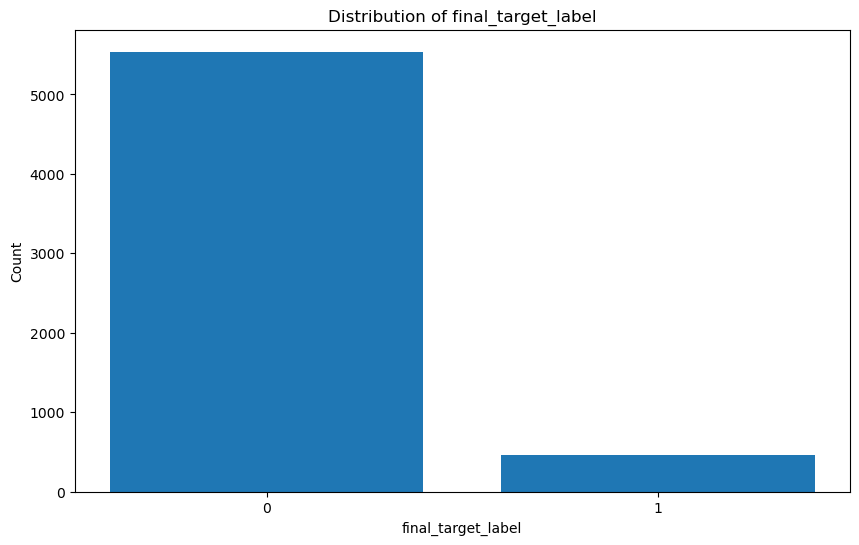

In [38]:
target_counts = df[target].value_counts().sort_index()
target_props = df[target].value_counts(normalize=True).sort_index() * 100

print("Target counts:")
display(target_counts)

print("Target percentages:")
display(target_props.round(2))

plt.figure()
plt.bar(target_counts.index.astype(str), target_counts.values)
plt.title("Distribution of final_target_label")
plt.xlabel("final_target_label")
plt.ylabel("Count")
plt.show()

# Visualizing each feature against the target

For categorical features, I will compare the `rate of target = 1` within each category.  
For numerica features, I will compare the score distributions for each target group.

In [39]:
def plot_target_rate_by_category(df, feature, target="final_target_label", sort_index=False):
    rate = df.groupby(feature)[target].mean().sort_values(ascending=False)
    counts = df[feature].value_counts()

    plt.figure(figsize=(10, 6))
    plt.bar(rate.index.astype(str), rate.values)
    plt.title(f"Rate of {target}=1 by {feature}")
    plt.xlabel(feature)
    plt.ylabel("Proportion of target = 1")
    plt.xticks(rotation=45, ha="right")
    plt.show()

    display(pd.DataFrame({
        "target_1_rate": rate,
        "count": counts.reindex(rate.index)
    }))

### Feature 1: `domain` vs `final_target_label`

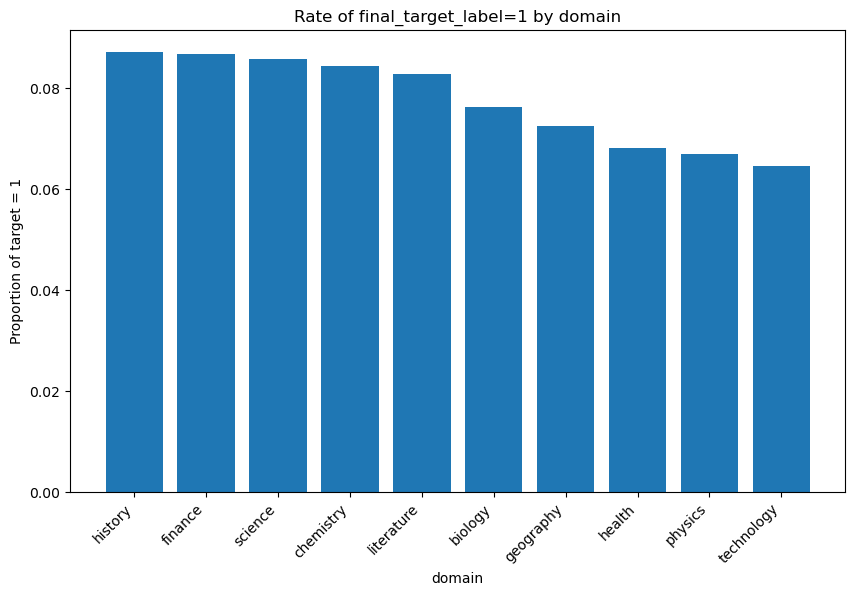

,target_1_rate,count
domain,,
history,0.087173,803
finance,0.086898,748
science,0.085890,489
chemistry,0.084367,403
literature,0.082927,410
biology,0.076355,406
geography,0.072519,786
health,0.068152,763
physics,0.066998,403


In [40]:
plot_target_rate_by_category(df, "domain", target)

### Feature 2: `hallucination_label_without_rag` vs `final_target_label`

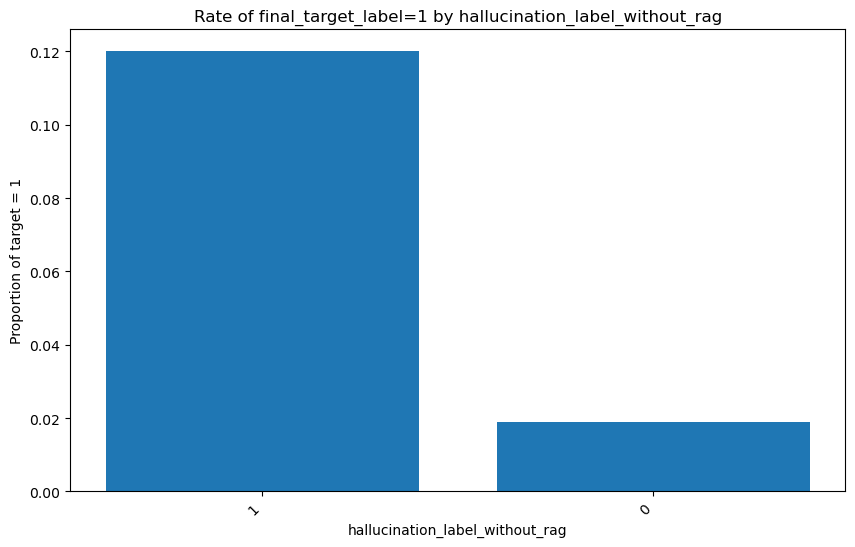

,target_1_rate,count
hallucination_label_without_rag,,
1,0.120012,3458
0,0.018883,2542


In [41]:
plot_target_rate_by_category(df, "hallucination_label_without_rag", target)

### Feature 3: `hallucination_label_with_rag` vs `final_target_label`

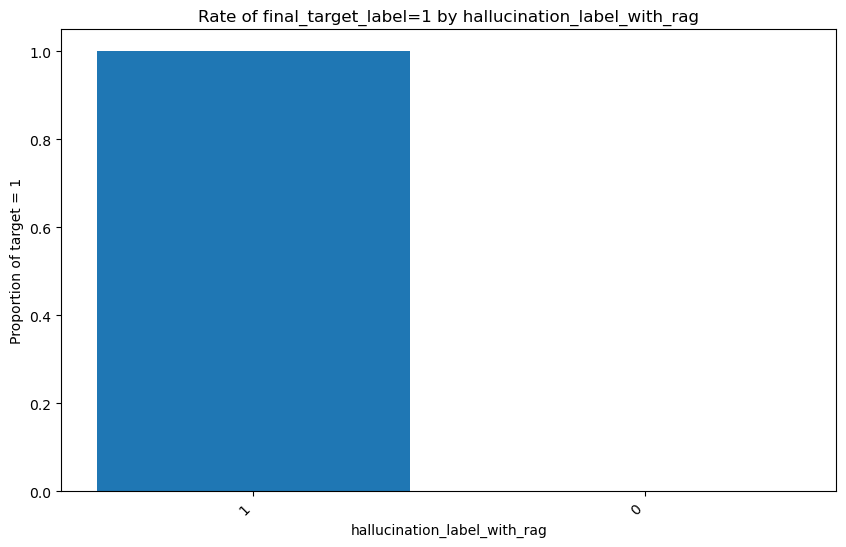

,target_1_rate,count
hallucination_label_with_rag,,
1,1.0,463
0,0.0,5537


In [42]:
plot_target_rate_by_category(df, "hallucination_label_with_rag", target)

### Feature 4: `hallucination_type` vs `final_target_label`

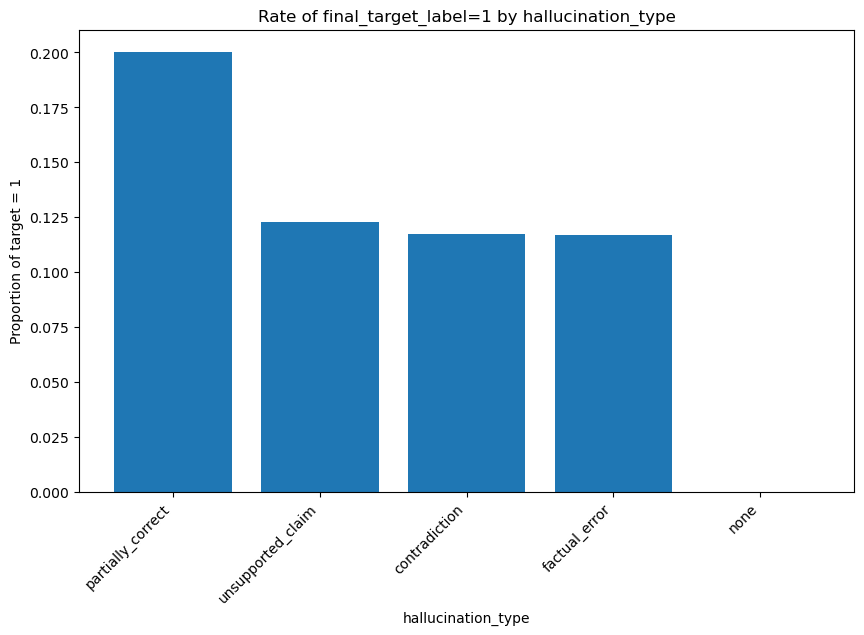

,target_1_rate,count
hallucination_type,,
partially_correct,0.200355,564
unsupported_claim,0.122613,995
contradiction,0.117227,981
factual_error,0.116977,966
none,0.000000,2494


In [43]:
plot_target_rate_by_category(df, "hallucination_type", target)

### Feature 5: `source_support_label` vs `final_target_label`

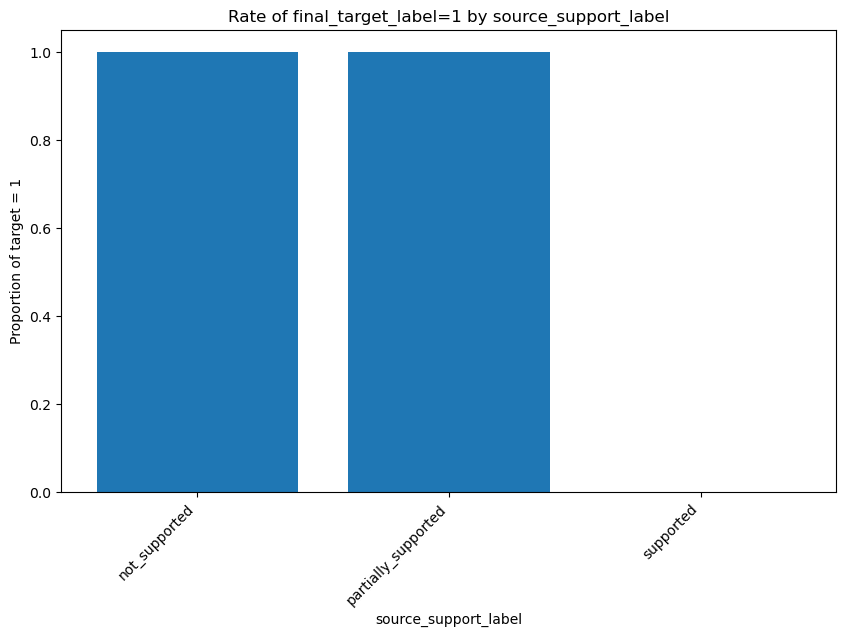

,target_1_rate,count
source_support_label,,
not_supported,1.0,227
partially_supported,1.0,236
supported,0.0,5537


In [44]:
plot_target_rate_by_category(df, "source_support_label", target)

### Feature 6: `factual_consistency_score` vs `final_target_label`

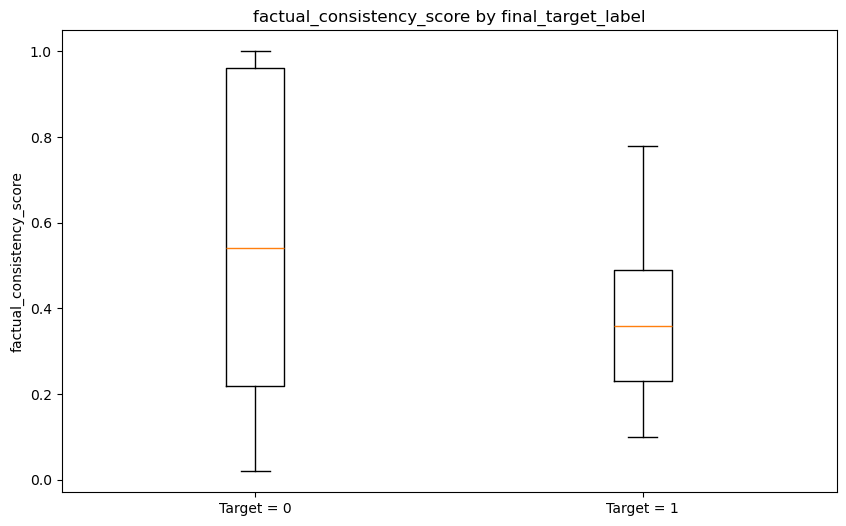

,count,mean,std,min,25%,50%,75%,max
final_target_label,,,,,,,,
0,5537.0,0.574520,0.366432,0.02,0.22,0.54,0.96,1.00
1,463.0,0.384665,0.189143,0.10,0.23,0.36,0.49,0.78


In [45]:
group0 = df[df[target] == 0]["factual_consistency_score"]
group1 = df[df[target] == 1]["factual_consistency_score"]

plt.figure(figsize=(10, 6))
plt.boxplot([group0, group1], tick_labels=["Target = 0", "Target = 1"])
plt.title("factual_consistency_score by final_target_label")
plt.ylabel("factual_consistency_score")
plt.show()

display(df.groupby(target)["factual_consistency_score"].describe())

### Feature 7: `context_relevance_score` vs `final_target_label`

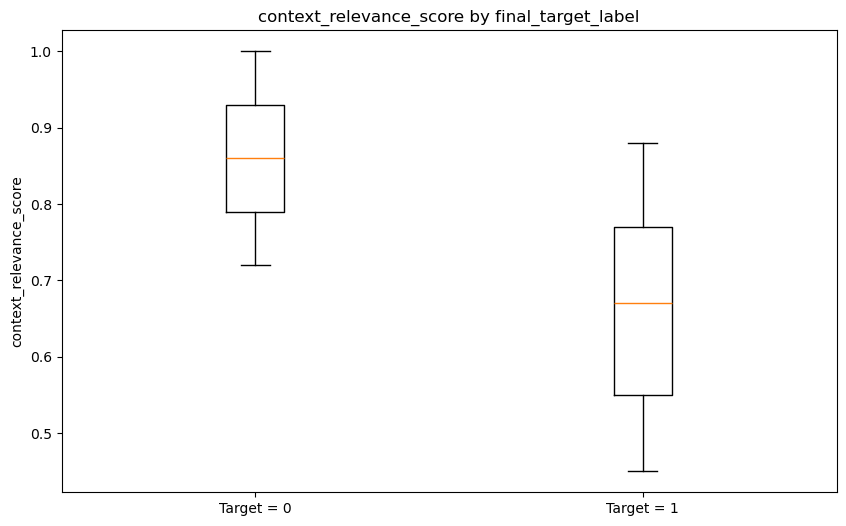

,count,mean,std,min,25%,50%,75%,max
final_target_label,,,,,,,,
0,5537.0,0.860789,0.081312,0.72,0.79,0.86,0.93,1.00
1,463.0,0.665486,0.125402,0.45,0.55,0.67,0.77,0.88


In [46]:
group0 = df[df[target] == 0]["context_relevance_score"]
group1 = df[df[target] == 1]["context_relevance_score"]

plt.figure(figsize=(10, 6))
plt.boxplot([group0, group1], tick_labels=["Target = 0", "Target = 1"])
plt.title("context_relevance_score by final_target_label")
plt.ylabel("context_relevance_score")
plt.show()

display(df.groupby(target)["context_relevance_score"].describe())

## Summary tables comparing feature strength

In [47]:
# Categorical feature summary
for col in ["domain", "hallucination_label_without_rag", "hallucination_label_with_rag", "hallucination_type", "source_support_label"]:
    print(f"\n=== {col} ===")
    summary = (
        df.groupby(col)[target]
        .agg(target_1_rate="mean", count="size")
        .sort_values("target_1_rate", ascending=False)
    )
    display(summary)


=== domain ===


,target_1_rate,count
domain,,
history,0.087173,803
finance,0.086898,748
science,0.085890,489
chemistry,0.084367,403
literature,0.082927,410
biology,0.076355,406
geography,0.072519,786
health,0.068152,763
physics,0.066998,403



=== hallucination_label_without_rag ===


,target_1_rate,count
hallucination_label_without_rag,,
1,0.120012,3458
0,0.018883,2542



=== hallucination_label_with_rag ===


,target_1_rate,count
hallucination_label_with_rag,,
1,1.0,463
0,0.0,5537



=== hallucination_type ===


,target_1_rate,count
hallucination_type,,
partially_correct,0.200355,564
unsupported_claim,0.122613,995
contradiction,0.117227,981
factual_error,0.116977,966
none,0.000000,2494



=== source_support_label ===


,target_1_rate,count
source_support_label,,
not_supported,1.0,227
partially_supported,1.0,236
supported,0.0,5537


In [48]:
# Numeric relationship summary
numeric_summary = df[[target, "factual_consistency_score", "context_relevance_score"]].corr(numeric_only=True)
display(numeric_summary)

,final_target_label,factual_consistency_score,context_relevance_score
final_target_label,1.000000,-0.140945,-0.520463
factual_consistency_score,-0.140945,1.000000,0.085947
context_relevance_score,-0.520463,0.085947,1.000000


## Interpretation and Conclusions

### Which features seem most related to the target?
From the visualizations and summary tables, the features that seem **most related** to `final_target_label` are:

1. **`hallucination_label_with_rag`**  
   This feature aligns almost perfectly with the target, which suggests it is extremely strongly related.

2. **`source_support_label`**  
   Records marked `supported` align with target `0`, while `partially_supported` and `not_supported` align with target `1`. This is also an extremely strong relationship.

3. **`context_relevance_score`**  
   Lower relevance scores tend to appear with target `1`, so this numeric feature appears strongly associated with hallucination risk.

4. **`hallucination_type`**  
   The category `none` strongly aligns with target `0`, while categories such as `partially_correct`, `contradiction`, `factual_error`, and `unsupported_claim` show higher hallucination rates.

### Which feature seems least related?
- **`domain`** appears to have the weakest relationship to the target.  
  Different subject areas have only modest differences in hallucination rate compared with the much stronger label-based and support-based features.

### Big picture conclusion
A major conclusion from this dataset is that **hallucination outcomes are much more strongly connected to retrieval quality and source support than to the knowledge domain itself**. In other words, whether the response is well-supported by retrieved evidence seems to matter far more than whether the question is about biology, history, finance, or technology.

### Additional observation
Because `hallucination_label_with_rag` and `source_support_label` are so strongly aligned with the target, they may contain information that is very close to the target definition itself. That means they are useful for explanation, but in a later machine learning project they might introduce **label leakage** if used carelessly.

## Final Summary
This dataset contains 6,000 examples of LLM responses with and without retrieval support, labeled for hallucination detection. I selected `final_target_label` as the target and analyzed its relationship to seven features: `domain`, `hallucination_label_without_rag`, `hallucination_label_with_rag`, `hallucination_type`, `factual_consistency_score`, `context_relevance_score`, and `source_support_label`. The visualizations showed that `hallucination_label_with_rag` and `source_support_label` were the features most strongly related to the target, while `domain` had the weakest relationship. The numeric plots also showed that lower `context_relevance_score` values were associated with hallucinated final responses. Overall, the data suggests that retrieval quality and source support are more important predictors of hallucination than the subject domain of the question.